In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv")

In [4]:
print("Columns:", df.columns)

Columns: Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [5]:
prices = df['price']

In [6]:
Q1 = np.percentile(prices, 25)
Q3 = np.percentile(prices, 75)
IQR = Q3 - Q1

In [7]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [8]:
outliers = prices[(prices < lower_bound) | (prices > upper_bound)]

25th percentile (Q1): $3,430,000.00
75th percentile (Q3): $5,740,000.00
IQR: $2,310,000.00
Lower Bound: $-35,000.00
Upper Bound: $9,205,000.00
Number of outliers: 15


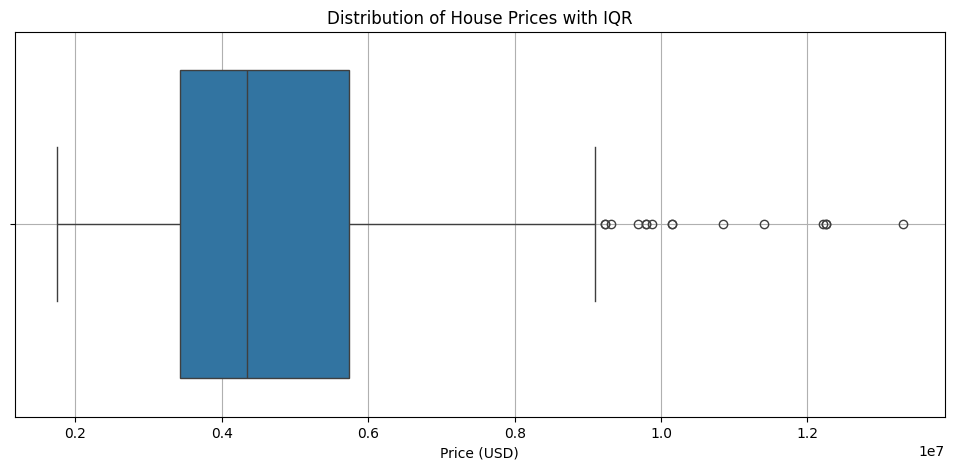

In [9]:
print(f"25th percentile (Q1): ${Q1:,.2f}")
print(f"75th percentile (Q3): ${Q3:,.2f}")
print(f"IQR: ${IQR:,.2f}")
print(f"Lower Bound: ${lower_bound:,.2f}")
print(f"Upper Bound: ${upper_bound:,.2f}")
print(f"Number of outliers: {len(outliers)}")
plt.figure(figsize=(12, 5))
sns.boxplot(x=prices)
plt.title("Distribution of House Prices with IQR")
plt.xlabel("Price (USD)")
plt.grid(True)
plt.show()